# Exploratory Data Analysis

1) Understanding Problem Statement
2) Data Collection
3) Data Cleaning
4) EDA
5) Data preprocessing
6) Model Training
7) Model Selection 

# 1) Problem Statement

Here , heart stroke prediction is performed on a dataset collected from kaggle. we have to predict the chance of a person will have the heart stroke based on features like age,gender,glucose level,smoking status,BMI,work type,residence type.

# 2) Import data
    
  importing libraries : pandas,numpy,matplotlib,seaborn etc.

In [1]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

## accesing data 

In [2]:
df=pd.read_csv("data/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# check shape of data : numer of rows and number of columns

In [3]:
df.shape

(5110, 12)

As the problem is a binary classification problem, check the data is imabalanced or not ?

In [4]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Note : Above outcome shows the data is imabalanced.

# Summary of the dataset

on numerical data check the summary

In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


check data types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# Exploring data 

In [7]:
numeric_features = [feature for feature in df.columns if df[feature].dtype !='O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [8]:
print(f"""The number of numeric features are {len(numeric_features)} and numeric features are 
      {numeric_features}\n""")

print(f"""The number of categorical features are {len(categorical_features)} and categorical features are
      {categorical_features}""")

The number of numeric features are 7 and numeric features are 
      ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

The number of categorical features are 5 and categorical features are
      ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


Feature Information

Here we are using the heart stroke dataset from kaggle for our analysis. This dataset consists of total 12 attributes or features.The complete descriptions of the attributes used in the project is given below.

1)  id : This feature is the person's id . a numerical unique value.
2)  Age : This features is about the person's age. Its a numerical data.
3)  Gender : This feature is about the peson's gender. Its a categorical data.
4)  Hypertension : This feature is about the person is hypertensive or not. Its a numerical data, but it's a kind of yes no data.
5)  work_type : This feature is about the person's work place.Its a categorical data.
6)  Residence_type : This feature is about the person's residence place. Its a categorical data.
7)  heart_disease : This feature is about the person is having heart disease or not. its a numerical data but yes or no kind.
8)  avg_glucose_level : This feature is about the person's glucose level.Its a numerical data.
9)  bmi : This feature is about the person's body mass index value. Its a numerical data.
10)  ever_married : This feature is about the person's married status. Its a categorical data.
11)  smoking_status : This feature is about the person's smoking habit.Its a categorical data.
12)  Stroke : This feature is about the person's had experienced stroke before or not.

In [9]:
# proportion of count data on categorical columns

for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print("################################")

gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: proportion, dtype: float64
################################
ever_married
Yes    65.616438
No     34.383562
Name: proportion, dtype: float64
################################
work_type
Private          57.240705
Self-employed    16.027397
children         13.444227
Govt_job         12.857143
Never_worked      0.430528
Name: proportion, dtype: float64
################################
Residence_type
Urban    50.802348
Rural    49.197652
Name: proportion, dtype: float64
################################
smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64
################################


# Univariate Analysis

Univariate analysis refers to the analysis of a single variable or feature .The purpose of analysis of single variable is to understand the distribution of values of the single feature.

Numerical Features

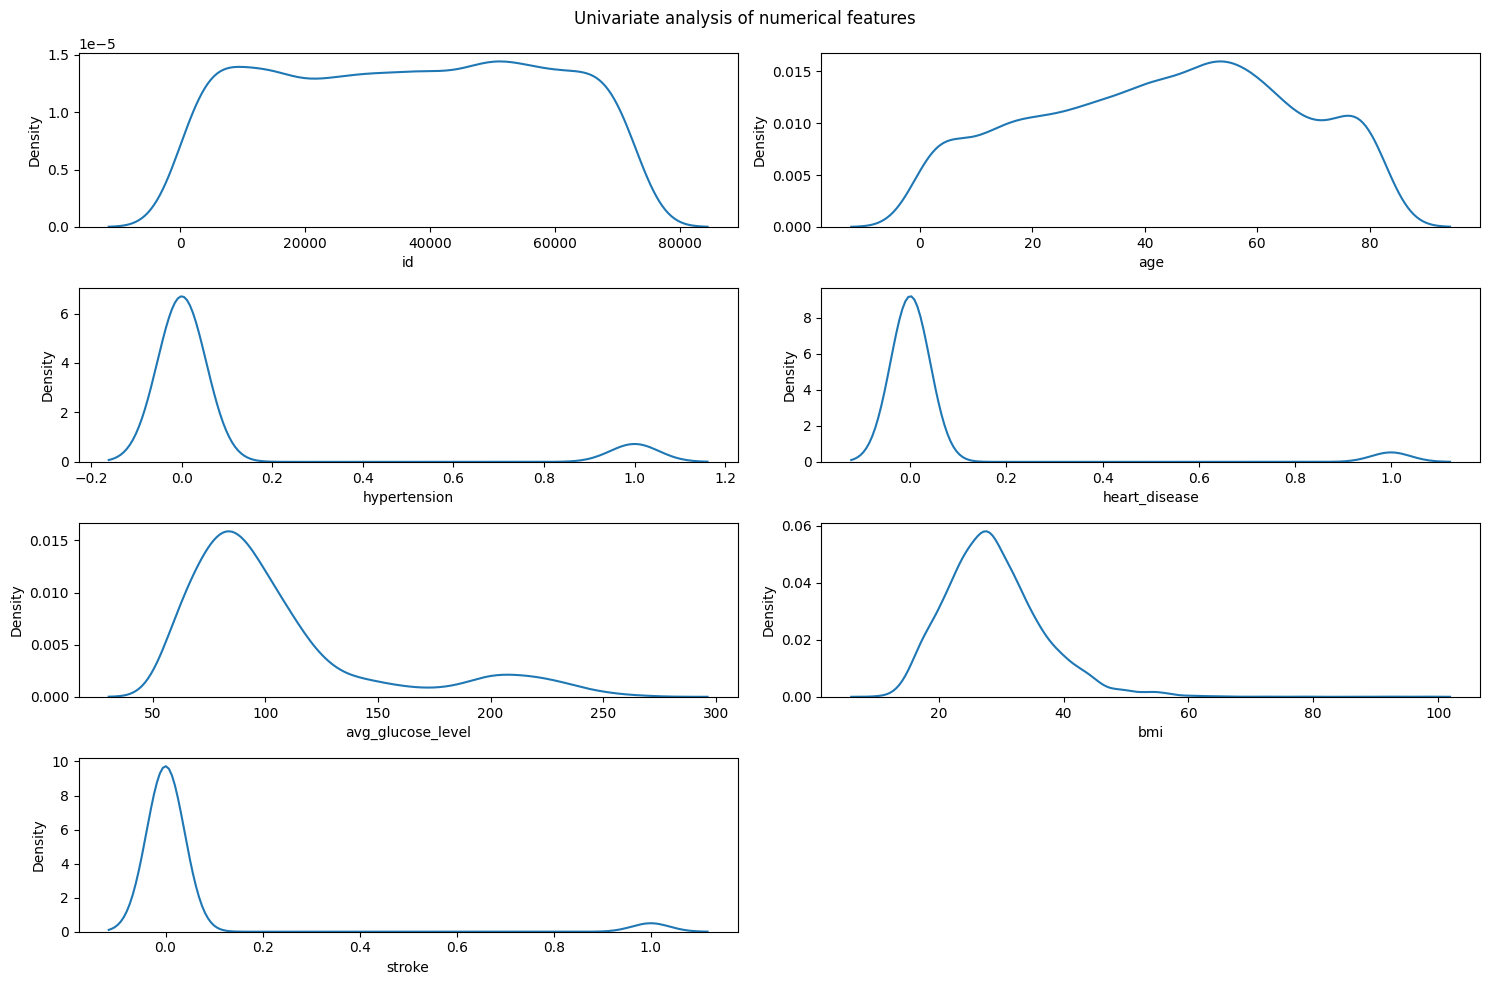

In [14]:
plt.figure(figsize=(15,10))
plt.suptitle("Univariate analysis of numerical features")

for i in range(0,len(numeric_features)):
    plt.subplot(4,2,i+1)
    sns.kdeplot(df[numeric_features[i]])
    plt.tight_layout()
    plt.savefig("univariate_analysis_numeric.jpeg")

univariate analysis of numerical features 

Report 

. age,bmi,avg_glucose_level are the continous features.

. id is a primary key of no use for model.

. hypertension,heart_disease,stroke are categorical features but encoded.

Categorical feature univariate analysis

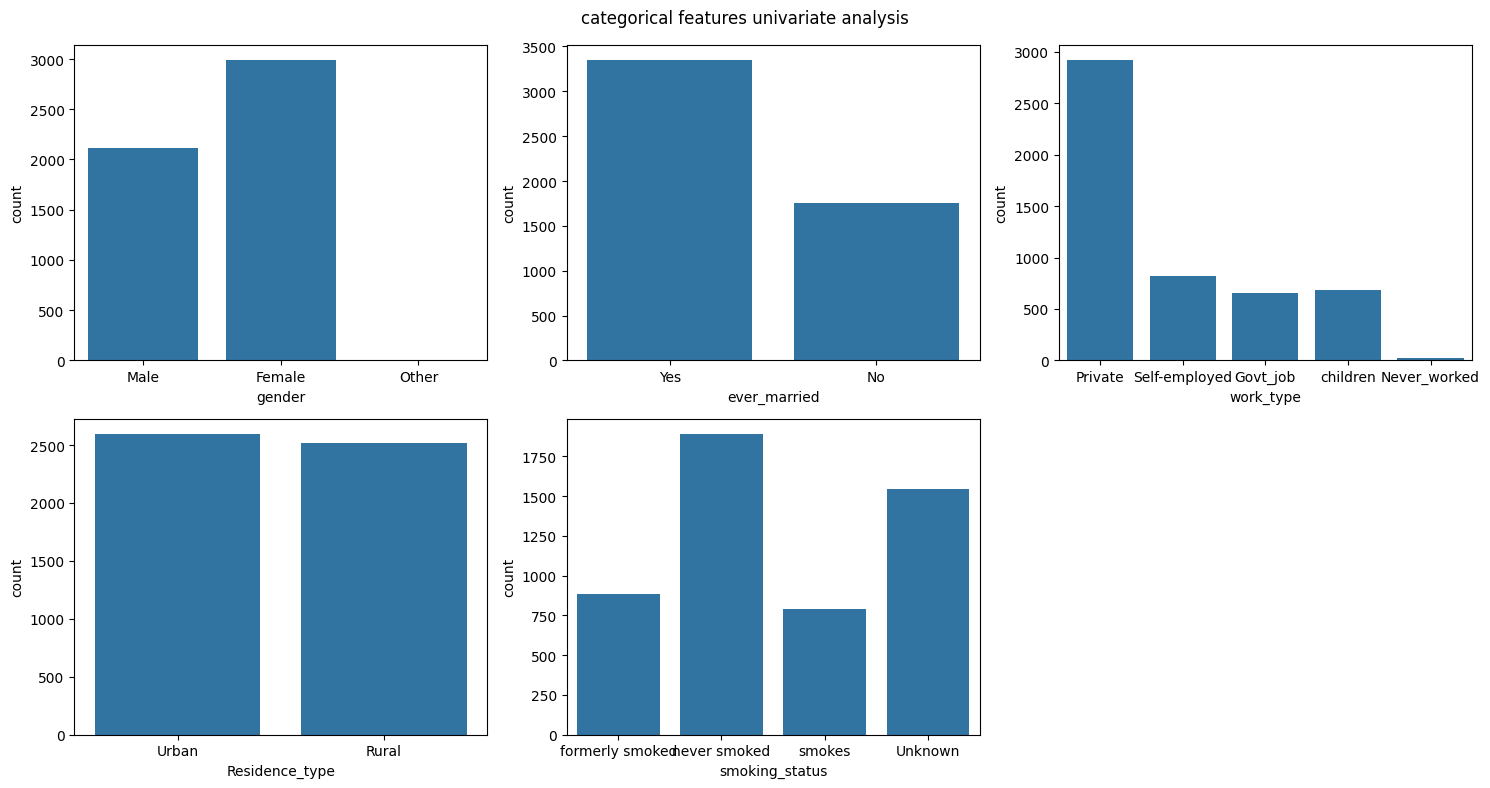

In [23]:
plt.figure(figsize=(15,8))
plt.suptitle("categorical features univariate analysis")

for i in range(0,len(categorical_features)):
    
    plt.subplot(2,3,i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tick_params()
    plt.tight_layout()

Report on categorical feature univariate analysis

1) Gender has other category very small
2) smoking has unknown category for whom smoking status is not availabel.

# Multivariate analysis

1) Multivariate analysis is the analysis of more than one variable. analysis of two or more variables.